# Libraries

In [133]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sci
from sklearn.metrics import r2_score
import pickle

# Dataset upload and computing error model

### $x$ data

In [134]:
filename = r'/home/wmpjrufg/Documents/ic_andre_rimes/gen_dataset/z_dataset_1_wexp_menos_wfib2020.pkl'
with open(filename, 'rb') as f:
    dataset_x = pickle.load(f)

In [135]:
dataset_x[1].head()

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,largura_da_viga_b_mm,altura_da_viga_h_mm,area_de_aco_tracionada_as_mm2,...,nbr_6118_wk2_fissuracao_nao_estabilizada,clark_1956,desayiganesan_1985,oh_kang_1987,caldas_1997,gergely_e_lutz_1968,equacao_15_do_artigo_de_belarbi_e_hsu_1994,beta_conforme_fields_e_bischoff_2004,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020
0,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.157380,0.181006,0.312684,0.185969,0.129998,0.241528,0.149956,0.116566,0.109686,0.082007
1,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.271111,0.244363,0.410398,0.256204,0.174746,0.317005,0.204348,0.197288,0.193326,0.156266
2,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.289281,0.253135,0.423928,0.265928,0.180941,0.327456,0.212052,0.208041,0.205301,0.167096
3,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.386596,0.296022,0.490072,0.313472,0.211232,0.378549,0.250139,0.259368,0.265222,0.221958
4,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.617471,0.379848,0.619355,0.406398,0.270437,0.478411,0.311870,0.354810,0.388948,0.338382


### $y$ data

In [136]:
data = pd.read_excel(r'/home/wmpjrufg/Documents/ic_andre_rimes/gen_dataset/data_models_rv2.xlsx', sheet_name='Modelos')
data.columns = data.columns.str.lower().str.replace(' ', '-')
data

,autor,output:-w_exp-(mm),fib-model-code-2020-(mm),wexp_menos_wfib2020,fib-model-code-2020--com-ts-variável-(mm),wexp_menos_wfib2020ts,norma-chinesa-(mm)
0,Viga S200-1.76-20 - Sokolov et al (2021),0.16,0.086159,0.073841,0.102130,0.057870,NaN
1,NaN,0.23,0.147127,0.082873,0.190783,0.039217,NaN
2,NaN,0.24,0.155568,0.084432,0.203058,0.036942,NaN
3,NaN,0.27,0.196838,0.073162,0.263069,0.006931,NaN
4,NaN,0.35,0.277502,0.072498,0.380363,-0.030363,NaN
...,...,...,...,...,...,...,...
336,NaN,0.19,0.217911,-0.027911,0.227492,-0.037492,NaN
337,NaN,0.22,0.247400,-0.027400,0.261534,-0.041534,NaN
338,Viga 23-6-11-2 - Clark (1956),0.17,0.150622,0.019378,0.150622,0.019378,NaN
339,Viga 23-6-11-3 - Clark (1956),0.19,0.108061,0.081939,0.108061,0.081939,NaN


### PySR model

In [137]:
filename = r'/home/wmpjrufg/Downloads/results_pysr_model_8020_dataset_1.pkl'
with open(filename, 'rb') as f:
    results_pysr_model_8020_dataset_1 = pickle.load(f)
    results_pysr_model_8020_dataset_1 = results_pysr_model_8020_dataset_1[1:]

### See best equation by R2 and Z-score parameters

In [138]:
df_models = {
                'r2 train': [],
                'r2 test': [],
                'rmse train': [],
                'rmse test': [],
                'score': [],
                'best equation': [],
            }
for idx, item in enumerate(results_pysr_model_8020_dataset_1):
    model = item["model"]
    df_models['r2 train'].append(model["train_r2"])
    df_models['r2 test'].append(model["test_r2"])
    df_models['rmse train'].append(model["train_rmse"])
    df_models['rmse test'].append(model["test_rmse"])
    df_models['score'].append(model["model_object"].get_best()['score'])
    df_models['best equation'].append(model["best_equation"])
df_models = pd.DataFrame(df_models)
df_models['gap rmse'] = abs(df_models['rmse train'] - df_models['rmse test'])
df_models['gap r2'] = abs(df_models['r2 train'] - df_models['r2 test'])
# df_models = df_models.sort_values(by='gap rmse')
# df_models = df_models.sort_values(by='gap r2')
df_models = df_models.sort_values(by='r2 train', ascending=False)
df_models.head()

,r2 train,r2 test,rmse train,rmse test,score,best equation,gap rmse,gap r2
14,0.690279,0.539447,0.042636,0.041304,0.064823,abs((equacao_15_do_artigo_de_belarbi_e_hsu_199...,0.001333,0.150832
11,0.689589,0.441879,0.042684,0.045469,0.084250,(area_de_aco_tracionada_as_mm2 + (abs(abs(cald...,0.002785,0.247709
46,0.688087,0.567777,0.039650,0.055071,0.111922,((abs(distancia_ao_centro_de_gravidade_da_arma...,0.015421,0.120310
61,0.671920,0.582246,0.042054,0.048474,0.099322,(sin(largura_da_viga_b_mm / -0.10914159) + (ar...,0.006420,0.089674
78,0.664560,0.549560,0.043203,0.046943,0.059257,((abs(sin((square(resistencia_a_tracao_do_conc...,0.003740,0.115001


In [139]:
best_index = df_models['r2 train'].idxmax()
best_index

14

In [140]:
equation = df_models.iloc[0]['best equation']
equation

'abs((equacao_15_do_artigo_de_belarbi_e_hsu_1994 + (((momento_fletor_ms_knm + sin(((cos(resistencia_do_aco_fy_mpa) * resistencia_a_tracao_do_concreto_mpa) - cobrimento_mm) - diametro_da_armadura_mm)) * 0.70674187) - nbr_6118_wk1_fissuracao_estabilizada)) * 0.089397915) - ((oh_kang_1987 + 1.1854273) * 0.016027365)'

In [ ]:
def computing_equation(df, lista_colunas, lista_medias, lista_desvios):
    df_z = df.copy()
    for col, mi, sigma in zip(lista_colunas, lista_medias, lista_desvios):
        if sigma != 0:
            df_z[col] = (df[col] - mi) / sigma
        else:
            df_z[col] = 0.0

    # Equation from the best model found by PySR
    equacao_15     = df_z['equacao_15_do_artigo_de_belarbi_e_hsu_1994']
    momento_fletor = df_z['momento_fletor_ms_knm']
    fy             = df_z['resistencia_do_aco_fy_mpa']
    ft             = df_z['resistencia_a_tracao_do_concreto_mpa']
    cobrimento     = df_z['cobrimento_mm']
    diametro       = df_z['diametro_da_armadura_mm']
    nbr_6118       = df_z['nbr_6118_wk1_fissuracao_estabilizada']
    oh_kang        = df_z['oh_kang_1987']

    theta = ft * np.cos(fy) - cobrimento - diametro
    alpha = (momento_fletor + np.sin(theta)) * 0.70674187
    omega = equacao_15 + alpha  - nbr_6118
    beta  = oh_kang + 1.1854273

    return 0.089397915 * np.abs(omega) -  beta * 0.016027365

In [142]:
results_pysr_model_8020_dataset_1[best_index]

{'diametro_da_armadura_mm': {'avg': 17.709705882352942,
  'std_dev': 6.203070627327441},
 'resistencia_do_aco_fy_mpa': {'avg': 470.90808823529414,
  'std_dev': 99.02184663523013},
 'numero_de_barras_em_uma_camada': {'avg': 2.5404411764705883,
  'std_dev': 1.4162335444488474},
 'espacamento_entre_as_barras_mm': {'avg': 64.17279411764706,
  'std_dev': 48.48892361427852},
 'resistencia_a_tracao_do_concreto_mpa': {'avg': 3.1113071657429816,
  'std_dev': 0.5125923894607325},
 'cobrimento_mm': {'avg': 32.85988970588235, 'std_dev': 10.936500995837418},
 'distancia_ao_centro_de_gravidade_da_armadura_mm': {'avg': 43.93051470588235,
  'std_dev': 12.394590365288929},
 'largura_da_viga_b_mm': {'avg': 204.4514705882353,
  'std_dev': 106.21676814925534},
 'altura_da_viga_h_mm': {'avg': 335.7764705882353,
  'std_dev': 112.4737696448887},
 'area_de_aco_tracionada_as_mm2': {'avg': 691.3981617647058,
  'std_dev': 607.3600071363603},
 'taxa_de_armadura_conforme_mc2020': {'avg': 0.025736705305598063,
  's

In [143]:
mycolumns = [
            'equacao_15_do_artigo_de_belarbi_e_hsu_1994',
            'momento_fletor_ms_knm',
            'resistencia_do_aco_fy_mpa',
            'resistencia_a_tracao_do_concreto_mpa',
            'cobrimento_mm',
            'diametro_da_armadura_mm',
            'nbr_6118_wk1_fissuracao_estabilizada',
            'oh_kang_1987'
        ]
avg = []
std = []
for j in mycolumns:
    avg.append(results_pysr_model_8020_dataset_1[best_index][j]['avg'])
    std.append(results_pysr_model_8020_dataset_1[best_index][j]['std_dev'])

### Build whole dataset to compare

In [144]:
w = dataset_x[1].copy()
w['output:-w_exp-(mm)'] = data['output:-w_exp-(mm)']
w['fib'] = data['fib-model-code-2020-(mm)']
w['error'] = computing_equation(w, mycolumns , avg, std)
w['wnum'] = w['fib'] + w['error']
w['wnum/wexp'] = w['wnum'] / w['output:-w_exp-(mm)']

In [145]:
w

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,largura_da_viga_b_mm,altura_da_viga_h_mm,area_de_aco_tracionada_as_mm2,...,gergely_e_lutz_1968,equacao_15_do_artigo_de_belarbi_e_hsu_1994,beta_conforme_fields_e_bischoff_2004,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020,output:-w_exp-(mm),fib,error,wnum,wnum/wexp
0,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.241528,0.149956,0.116566,0.109686,0.082007,0.16,0.086159,0.087912,0.174071,1.087944
1,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.317005,0.204348,0.197288,0.193326,0.156266,0.23,0.147127,0.104085,0.251212,1.092225
2,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.327456,0.212052,0.208041,0.205301,0.167096,0.24,0.155568,0.106156,0.261724,1.090518
3,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.378549,0.250139,0.259368,0.265222,0.221958,0.27,0.196838,0.115870,0.312708,1.158177
4,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.478411,0.311870,0.354810,0.388948,0.338382,0.35,0.277502,0.147231,0.424734,1.213525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,28.7,276,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,...,0.235766,0.238556,0.233751,0.326560,0.266684,0.19,0.217911,0.028509,0.246420,1.296948
337,28.7,276,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,...,0.262014,0.247400,0.266497,0.378289,0.310953,0.22,0.247400,0.035874,0.283274,1.287609
338,35.8,276,2,36.4,2.547836,38.0,55.9,152.4,584.2,2012.0,...,0.187961,0.165331,0.155387,0.253458,0.182233,0.17,0.150622,0.093278,0.243900,1.434704
339,35.8,276,2,36.4,2.756373,38.0,55.9,152.4,584.2,2012.0,...,0.146565,0.125892,0.108061,0.170128,0.122579,0.19,0.108061,0.080287,0.188348,0.991304


In [146]:
data = w.copy()
data.head()

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,largura_da_viga_b_mm,altura_da_viga_h_mm,area_de_aco_tracionada_as_mm2,...,gergely_e_lutz_1968,equacao_15_do_artigo_de_belarbi_e_hsu_1994,beta_conforme_fields_e_bischoff_2004,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020,output:-w_exp-(mm),fib,error,wnum,wnum/wexp
0,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.241528,0.149956,0.116566,0.109686,0.082007,0.16,0.086159,0.087912,0.174071,1.087944
1,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.317005,0.204348,0.197288,0.193326,0.156266,0.23,0.147127,0.104085,0.251212,1.092225
2,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.327456,0.212052,0.208041,0.205301,0.167096,0.24,0.155568,0.106156,0.261724,1.090518
3,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.378549,0.250139,0.259368,0.265222,0.221958,0.27,0.196838,0.115870,0.312708,1.158177
4,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.478411,0.311870,0.354810,0.388948,0.338382,0.35,0.277502,0.147231,0.424734,1.213525


### Mean and standard deviation

In [147]:
data.describe()

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,largura_da_viga_b_mm,altura_da_viga_h_mm,area_de_aco_tracionada_as_mm2,...,gergely_e_lutz_1968,equacao_15_do_artigo_de_belarbi_e_hsu_1994,beta_conforme_fields_e_bischoff_2004,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020,output:-w_exp-(mm),fib,error,wnum,wnum/wexp
count,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,...,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000
mean,17.881056,468.002933,2.492669,63.850254,3.090431,32.846188,43.834604,202.572141,337.636950,680.651320,...,0.280588,0.274002,0.271735,0.276129,0.240335,0.261672,0.214851,0.048135,0.262986,1.025300
std,6.258067,102.262652,1.364715,46.751976,0.501076,10.776445,12.213950,104.753565,111.788192,585.507137,...,0.076230,0.091358,0.111409,0.129666,0.109379,0.115072,0.082905,0.062278,0.110766,0.173671
min,9.520000,276.000000,1.000000,12.000000,2.384602,12.800000,23.900000,100.000000,161.000000,78.500000,...,0.096138,0.089892,0.052197,0.070935,0.051614,0.140000,0.052197,-0.054618,0.074380,0.371901
25%,12.000000,392.000000,2.000000,40.000000,2.800000,25.000000,35.000000,150.000000,250.000000,315.000000,...,0.220388,0.209395,0.187933,0.191853,0.168592,0.190000,0.156100,0.000235,0.193620,0.902032
50%,16.000000,500.000000,2.000000,46.000000,2.920876,30.000000,40.500000,152.400000,348.000000,452.000000,...,0.281083,0.260001,0.260513,0.255402,0.221958,0.230000,0.205276,0.033279,0.239251,1.009752
75%,20.000000,528.000000,3.000000,69.800000,3.269000,40.000000,49.100000,250.000000,381.000000,800.000000,...,0.329113,0.324399,0.338662,0.338895,0.296132,0.300000,0.261428,0.072710,0.283835,1.124316
max,35.800000,628.000000,9.000000,296.000000,5.308474,70.000000,94.500000,600.000000,604.000000,2826.000000,...,0.520959,0.573472,0.656073,0.913442,0.676814,0.790000,0.514251,0.248558,0.739596,1.699028


### $R^2$

In [148]:
obs = data['output:-w_exp-(mm)']
pred = data['wnum']
r2_fib_model_2020 = r2_score(obs, pred)
r2_fib_model_2020

0.8640278892660739

# Charts

In [149]:
name = 'fib_model_2020-pysr-model-dataset-1-8020'

### Predict versus Experimental

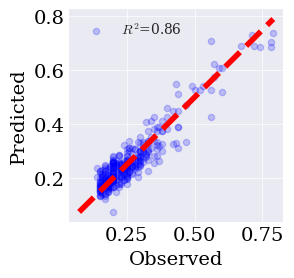

In [150]:
dpi = 600               # Change as you wish
b_cm = 7                       # Change as you wish
h_cm = 7                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm
label_x = 'Observed'            # Change as you wish
label_y = 'Predicted'           # Change as you wish
size_label = 14                 # Change as you wish
color_label = 'black'            # or hexadecimal. Change as you wish
size_axis = 14                  # Change as you wish
color_axis = 'black'              # or hexadecimal. Change as you wish
size_line = 4           # Change as you wish
style_line = '--'       # Change as you wish
color_line = 'red'      # or hexadecimal. Change as you wish
labels_legend = [rf'$R^2$={r2_fib_model_2020:.2f}']   # Change as you wish
size_legend = 10                # Change as you wish
location_legend = 'upper left'  # Change as you wish - 'best' look up by the best fit
fig, ax = plt.subplots(figsize=(b_input, h_input))
lims = [
            min(data['output:-w_exp-(mm)'].min(), data['wnum'].min()),
            max(data['output:-w_exp-(mm)'].max(), data['wnum'].max())
        ]

# Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

# Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.5)

# Plot data y = x and scatter
ax.plot(lims, lims, linewidth=size_line, linestyle=style_line, color=color_line,)
ax.scatter(data["output:-w_exp-(mm)"], data["wnum"], alpha=0.2, color='blue', s=20, label=labels_legend[0])
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_scatter-line_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

### KDE numerical model - original model

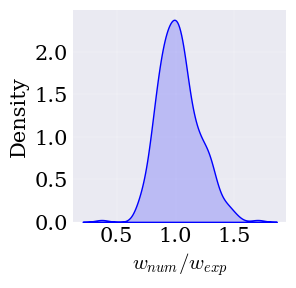

In [151]:
dpi = 600               

b_cm = 7            
h_cm = 7
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

label_y = 'Density'
label_x = '$w_{num}/w_{exp}$'   
size_label = 15
color_label = 'black'
size_axis = 15
color_axis = 'black'           

labels_legend = ['fib Model 2020']   
size_legend = 9                
location_legend = 'upper right'  

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=data, x='wnum/wexp', fill=True, alpha=0.2, color='blue', ax=ax, label=labels_legend[0])
# ax.legend(fontsize=size_legend, loc=location_legend)
fig.savefig(f'z_kde_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

# Goodness-of-fit

### Anderson-Darling test

Normal

In [152]:
# alpha = 5
# res = sci.stats.anderson(np.log(data['wnum/wexp']), dist="norm")
# stat = res.statistic
# crit = res.critical_values[res.significance_level == alpha][0]
# decision = "Accepted" if stat < crit else "Rejected"
# print(f"AD Statistic: {stat:.4f}")
# print(f"Critical Value at {alpha}% significance level: {crit:.4f}")
# print(f"Null Hypothesis: {decision}")

### Kolmogorov-Smirnov test

t-student

In [153]:
x = data['wnum/wexp'].values
df, loc, scale = sci.stats.t.fit(x)
print(f"\nFitted Student-t parameters:\nDegrees of freedom: {df:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 't', args=(df, loc, scale))
print("\nKolmogorov-Smirnov Test for Student-t Distribution:")
print(f"Student-t KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Student-t parameters:
Degrees of freedom: 13.2945, Location: 1.0202, Scale: 0.1598

Kolmogorov-Smirnov Test for Student-t Distribution:
Student-t KS statistic: 0.0501
p-value: 0.3472


Normal

In [154]:
x = data['wnum/wexp'].values
loc, scale = sci.stats.norm.fit(x)
print(f"\nFitted Normal parameters:\nLocation: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'norm', args=(loc, scale))
print("\nKolmogorov-Smirnov Test for Normal Distribution:")
print(f"Normal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Normal parameters:
Location: 1.0253, Scale: 0.1734

Kolmogorov-Smirnov Test for Normal Distribution:
Normal KS statistic: 0.0636
p-value: 0.1213


Log-normal

In [155]:
x = data['wnum/wexp'].values
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.0991, Location: -0.7122, Scale: 1.7289

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0438
p-value: 0.5169


### Genetate statistics for Lognormal

In [156]:
mu = np.log(scale)
sigma = shape

mean = loc + np.exp(mu + 0.5*sigma**2)
var = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std = np.sqrt(var)

print("\nLognormal Distribution Moments after fitting:")
print(f"Mean = {mean:.3f}")
print(f"Std  = {std:.3f}")


Lognormal Distribution Moments after fitting:
Mean = 1.025
Std  = 0.173


#### Generate synthetic data

In [157]:
sigma = np.sqrt(np.log(1 + (std / mean)**2))
mu = np.log(mean) - 0.5 * sigma**2

shape = sigma
loc = 0.0
scale = np.exp(mu)

print(f"shape = {shape:.4f}")
print(f"loc   = {loc:.4f}")
print(f"scale = {scale:.4f}")

n_samples = 20000
synthetic_data = sci.stats.lognorm.rvs(s=shape, loc=loc, scale=scale, size=n_samples)

shape = 0.1672
loc   = 0.0000
scale = 1.0110


In [158]:
# Double check the fit on the synthetic data
x = synthetic_data.copy()
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.1691, Location: 0.0182, Scale: 0.9942

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0034
p-value: 0.9735


#### Synthetic data versus original data

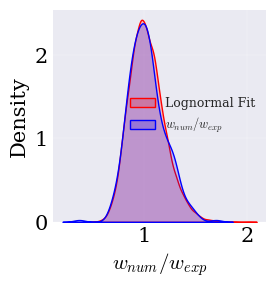

In [159]:
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=synthetic_data, fill=True, alpha=0.2, color='red', label='Lognormal Fit', ax=ax)
sns.kdeplot(data=list(data['wnum/wexp']), fill=True, alpha=0.2, color='blue', label='$w_{num}/w_{exp}$', ax=ax)
ax.legend(fontsize=size_legend, loc='center right')
fig.savefig(f'z_kde_{name}_gt_versus_lognormal.png', dpi=dpi, bbox_inches='tight')
plt.show()